# Лабораторная работа № 1. Регрессия на основе нейронных сетей
**Цель лабораторной работы** -- получение навыков работы с моделями глубоких нейронных сетей для решения задачи регрессии.

В рамках данной работы решается задача автоматического расчета стоимости страхового убытка на основе исторического набора данных Allstate Claims Severity (соревнование на платформе Kaggle). Каждая строка датасета представляет собой уникальный страховой случай с набором анонимизированных факторов.

* *Тип задачи*: Задача многомерной нелинейной регрессии (Regression Task).

* *Прогнозируемая целевая переменная*: Непрерывная величина в колонке loss -- размер финальной страховой выплаты в условных единицах (долларах).

* *Критерий качества*: Основной метрикой оптимизации и оценки модели является средняя абсолютная ошибка (MAE -- Mean Absolute Error), которая оценивает среднее отклонение прогноза от реальности в исходном долларовом масштабе. Для дополнительного контроля крупных промахов и выбросов рассчитывается среднеквадратическая ошибка (RMSE -- Root Mean Squared Error).



In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

Для автоматизации анализа данных и контроля предобработки были написаны три функции. Они помогают визуально оценить распределение признаков и найти сильные взаимосвязи между ними.

* **`ensure_dataframe`** -- проверяет тип входных данных. Если на вход подан массив `numpy`, функция преобразует его в `DataFrame` с правильными названиями колонок, чтобы с данными было удобно работать дальше.
* **`draw_boxplot`** -- строит график «ящик с усами» для визуализации разброса непрерывных признаков. Также функция рассчитывает среднее значение по выборке и отмечает его красной пунктирной линией. Это нужно для проверки результатов масштабирования.
* **`draw_corr_matrix`** -- рассчитывает матрицу линейной корреляции и строит её тепловую карту.
* **`draw_residual_plot`** -- рисуем график остатков. По сути разницы между реальными ответами и прогнозами модели.

In [2]:
def ensure_dataframe(data: pd.DataFrame | np.ndarray, column_names: list[str]) -> pd.DataFrame:
    if isinstance(data, pd.DataFrame):
        return data[column_names]
    else:
        return pd.DataFrame(data, columns=column_names)


def draw_boxplot(data: pd.DataFrame | np.ndarray, column_names: list[str], title: str) -> None:
    df = ensure_dataframe(data, column_names)
    mean_value = df.mean().mean()

    plt.figure(figsize=(14, 10))
    sns.boxplot(data=df, palette="coolwarm")

    plt.axhline(y=mean_value, color='red', linestyle='--', label='Mean')
    plt.ylabel(ylabel="Value")
    plt.xlabel(xlabel="Feature")

    plt.title(label=title)
    plt.legend()
    plt.show()


def draw_corr_matrix(data, column_names, title):
    df = ensure_dataframe(data, column_names)
    corr_matrix = df.corr().abs()

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")

    plt.title(label=title)
    plt.show()


def draw_residual_plot(y_true: np.ndarray, y_pred: np.ndarray, title: str = "Residual Plot") -> None:
    residuals = y_true - y_pred

    plt.figure(figsize=(14, 10))
    sns.scatterplot(x=y_pred, y=residuals, color="purple")

    plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")

    plt.title(label=title)
    plt.show()


В этой ячейке задаются ключевые настройки для обработки данных и пути к файлам проекта. Работа организована через библиотеку `pathlib`, что делает код независимым от операционной системы.

* **`chunk_size`** -- размер блока данных (20 000 строк) для последовательного чтения больших файлов, чтобы эффективно использовать оперативную память.
* **`corr_threshold = 0.9`** -- критический порог корреляции признаков. Если линейная связь между двумя фичами выше `0.9`, один из них будет удален как избыточный.

* **Структурирование папок (`Path`)**:
  * `raw/` -- оригинальные, неизмененные датасеты Allstate, загруженные из Kaggle.
  * `split/` -- промежуточные файлы после разделения выборки на обучение и локальный тест.
  * `processed/` -- финальные, полностью предобработанные матрицы в сжатом формате `.npz`, готовые к подаче в нейросеть Keras.

>Сугубо структура папок локально, так как github не дает грузить >100 мб.

In [3]:
chunk_size = 2 * 10 ** 4
corr_threshold = 0.9

work_dir = Path.cwd().absolute()
raw_train_path = work_dir / "data" / "raw" / "train.csv"
raw_test_path = work_dir / "data" / "raw" / "test.csv"

split_train_path = work_dir / "data" / "split" / "train_split.csv"
split_val_path = work_dir / "data" / "split" / "val_split.csv"

processed_train_path = work_dir / "data" / "processed" / "train_processed.npz"
processed_val_path = work_dir / "data" / "processed" / "val_processed.npz"


В этой ячейке исходный файл `train.csv` разбивается на две части в пропорции 80% на 20% с помощью функции `train_test_split`.

> Чтение файла настроено через блоки (`chunksize`) в цикле. На самом деле, для этого датасета весом в 50 МБ такой подход избыточен, и данные можно было загрузить целиком. Я использовал чанки сугубо в учебных целях, чтобы протестировать, как работает итеративная обработка тяжелых файлов.

Флаг `is_first` нужен просто для того, чтобы названия колонок (`header`) записались в итоговые файлы только один раз -- в самом начале.

In [4]:
is_first = True
chunk_iterator = pd.read_csv(raw_train_path, chunksize=chunk_size)
for chunk in chunk_iterator:
    train_chunk, val_chunk = train_test_split(chunk, test_size=0.2)

    train_chunk.to_csv(split_train_path, mode="a", index=False, header=is_first)
    val_chunk.to_csv(split_val_path, mode="a", index=False, header=is_first)
    is_first = False

После того как исходный датасет был разбит на чанки и записан в файлы, мы загружаем получившиеся выборки `train_split.csv` и `val_split.csv` обратно в память через `pd.read_csv`.

In [5]:
train_df = pd.read_csv(split_train_path)
val_df = pd.read_csv(split_val_path)

В этом блоке выполняется серия стандартных команд Pandas для детального осмотра обеих выборок (`train_df` и `val_df`) перед началом предобработки. Это необходимо, чтобы изучить типы признаков и проверить их размерность.

In [6]:
train_df.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,11904,A,A,A,A,A,B,A,A,A,...,0.772029,0.871745,0.31280,0.45391,0.57716,0.588753,0.576121,0.793584,0.757049,3604.15
1,15210,A,B,A,A,B,A,A,A,B,...,0.304628,0.381883,0.58354,0.46226,0.38016,0.341813,0.352251,0.339244,0.384757,3783.35
2,40535,A,A,A,B,A,A,A,A,A,...,0.197932,0.314927,0.41762,0.26401,0.23545,0.207238,0.204687,0.271571,0.793119,6322.73
3,37388,A,B,A,A,A,A,A,A,B,...,0.410193,0.349614,0.60087,0.43524,0.51111,0.776962,0.798279,0.354344,0.421363,1246.76
4,14218,A,A,A,A,B,A,A,A,A,...,0.399991,0.613736,0.36636,0.42700,0.41204,0.334828,0.328268,0.363547,0.255055,2270.87


In [7]:
train_df.tail()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
150649,577421,B,A,A,A,A,B,A,A,A,...,0.741764,0.643043,0.33372,0.45183,0.57716,0.441763,0.443374,0.753989,0.599454,1006.01
150650,563101,B,A,A,B,A,A,A,A,A,...,0.234324,0.324913,0.50060,0.33611,0.31480,0.269248,0.264760,0.333292,0.294597,3507.79
150651,582236,B,A,A,A,B,B,A,A,A,...,0.532062,0.770865,0.41762,0.44352,0.54433,0.797841,0.843026,0.354344,0.782307,1047.53
150652,583414,A,B,A,A,A,B,A,A,B,...,0.314937,0.413673,0.67263,0.38249,0.29595,0.228492,0.225288,0.363547,0.836936,2586.41
150653,586053,A,A,A,B,A,A,A,A,A,...,0.813282,0.623586,0.50060,0.80668,0.68520,0.727671,0.714544,0.842905,0.619527,2764.60


In [8]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150654 entries, 0 to 150653
Columns: 132 entries, id to loss
dtypes: float64(15), int64(1), str(116)
memory usage: 151.7 MB


In [9]:
train_df.describe()

,id,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
count,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000,150654.000000
mean,294117.943865,0.493637,0.507538,0.499372,0.491474,0.487323,0.490989,0.485297,0.486278,0.485337,0.497919,0.493745,0.493387,0.493035,0.495108,3037.265157
std,169362.961141,0.187554,0.207241,0.202076,0.211228,0.208960,0.205457,0.178850,0.199431,0.181568,0.185838,0.209844,0.209543,0.212762,0.222448,2916.422117
min,5.000000,0.000016,0.001149,0.002634,0.176921,0.281143,0.012683,0.069503,0.236880,0.000080,0.000000,0.035321,0.036232,0.000228,0.179722,0.670000
25%,147668.500000,0.344779,0.358319,0.336963,0.327354,0.281143,0.336105,0.350175,0.312800,0.358970,0.364580,0.310961,0.314945,0.315758,0.294583,1203.025000
50%,294681.500000,0.475784,0.555782,0.527991,0.452887,0.422268,0.440945,0.438407,0.441060,0.437310,0.461190,0.457203,0.462286,0.363547,0.406710,2111.720000
75%,440696.500000,0.623912,0.681761,0.634224,0.652072,0.635304,0.655021,0.591403,0.623580,0.566820,0.614590,0.678924,0.679096,0.689974,0.724551,3860.347500
max,587633.000000,0.984975,0.862654,0.944251,0.952482,0.982520,0.997162,1.000000,0.980200,0.995400,0.994980,0.998742,0.998484,0.988494,0.844848,121012.250000


In [10]:
train_df.shape

(150654, 132)

In [11]:
val_df.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1809,A,B,A,A,B,A,A,A,B,...,0.371301,0.433431,0.41762,0.35897,0.26894,0.317685,0.328268,0.345247,0.253849,7850.93
1,54050,A,B,A,A,A,A,A,A,B,...,0.460158,0.467749,0.29758,0.50420,0.54983,0.453334,0.462286,0.312885,0.386601,3903.22
2,3667,A,A,A,B,A,B,A,A,A,...,0.331919,0.336160,0.36083,0.39849,0.39599,0.297750,0.301921,0.351299,0.189563,979.67
3,23985,A,A,A,A,A,B,A,A,A,...,0.331398,0.361715,0.56600,0.39648,0.32935,0.245410,0.255941,0.295948,0.806622,1938.27
4,59666,A,A,A,B,A,A,A,A,A,...,0.876865,0.740556,0.68823,0.71934,0.81591,0.837272,0.826178,0.870644,0.805075,1117.98


In [12]:
val_df.tail()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
37659,564634,B,A,A,A,B,A,A,A,A,...,0.373500,0.377003,0.36083,0.44352,0.45017,0.338312,0.366307,0.339244,0.320731,1463.13
37660,561869,A,B,A,A,B,A,A,A,B,...,0.240069,0.279895,0.24564,0.30859,0.32446,0.223038,0.220003,0.333292,0.378901,1534.59
37661,563002,B,B,A,A,B,A,A,A,A,...,0.776551,0.895060,0.31280,0.50840,0.68039,0.936962,0.930665,0.630260,0.602751,1769.71
37662,570593,A,A,A,B,A,B,A,A,A,...,0.646200,0.435614,0.64027,0.83272,0.46119,0.377724,0.369858,0.761333,0.544229,1498.95
37663,585243,B,A,A,A,B,A,A,A,A,...,0.648884,0.345027,0.75525,0.64296,0.78770,0.784967,0.772574,0.751507,0.353209,996.00


In [13]:
val_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37664 entries, 0 to 37663
Columns: 132 entries, id to loss
dtypes: float64(15), int64(1), str(116)
memory usage: 37.9 MB


In [14]:
val_df.describe()

,id,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
count,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000,37664.000000
mean,294208.136390,0.494759,0.505789,0.497104,0.493164,0.487846,0.490768,0.483661,0.487075,0.486185,0.498655,0.492577,0.492205,0.493547,0.498152,3037.627796
std,169230.766599,0.187984,0.207042,0.202213,0.211547,0.209296,0.204535,0.176839,0.199131,0.182029,0.186033,0.209307,0.208962,0.212840,0.222633,2854.248227
min,1.000000,0.000016,0.002571,0.002634,0.176921,0.281143,0.012683,0.069503,0.236880,0.000080,0.000000,0.035321,0.036232,0.000228,0.180608,5.250000
25%,148092.750000,0.347403,0.358319,0.336963,0.327354,0.281143,0.335580,0.350175,0.317960,0.358970,0.364580,0.307628,0.308395,0.315758,0.295480,1209.922500
50%,293945.000000,0.475784,0.555782,0.506105,0.452887,0.422268,0.440945,0.438285,0.441060,0.441450,0.461190,0.457203,0.462286,0.363547,0.411944,2132.750000
75%,440609.250000,0.629339,0.681761,0.634224,0.661283,0.643315,0.654224,0.590091,0.623580,0.568890,0.619840,0.678924,0.675759,0.689974,0.725140,3879.030000
max,587620.000000,0.984452,0.862654,0.944251,0.954297,0.983674,0.997162,1.000000,0.980200,0.993790,0.994750,0.997796,0.997376,0.988494,0.844729,79623.520000


In [15]:
val_df.shape

(37664, 132)


В этой ячейке выполняется проверка обучающей и валидационной выборок на наличие пропущенных значений (NaN) с помощью комбинации методов `isna().sum()`.




In [16]:
print(train_df.isna().sum())
print(val_df.isna().sum())

id        0
cat1      0
cat2      0
cat3      0
cat4      0
         ..
cont11    0
cont12    0
cont13    0
cont14    0
loss      0
Length: 132, dtype: int64
id        0
cat1      0
cat2      0
cat3      0
cat4      0
         ..
cont11    0
cont12    0
cont13    0
cont14    0
loss      0
Length: 132, dtype: int64


По всем колонкам метод вернул нули. Это подтверждает, что в исходном датасете Allstate отсутствуют скрытые или явные пропуски.
Таким образом, этап заполнения пустых ячеек (импутация) нам не требуется, и все строки гарантированно сохраняются для обучения нейросети.

В этой ячейке проверяется наличие полностью повторяющихся строк (дубликатов) в данных с помощью метода `duplicated().sum()`.



In [17]:
print(train_df.duplicated().sum())
print(train_df.duplicated().sum())

0
0


Метод вернул 0 для обеих проверок. Это означает, что в датасете нет дублирующихся записей, данные уникальны и никакой принудительной очистки строк перед обучением делать не нужно.






В этой ячейке мы смотрим, сколько уникальных значений содержится в каждой колонке с помощью метода `nunique()`. Чтобы вывод был читаемым, категории и числа разделены. Заодно выделим категории по разным переменным.


In [18]:
cat_cols = [col for col in train_df.columns if col.startswith("cat")]
num_cols = [col for col in train_df.columns if col.startswith("cont")]

print(train_df[cat_cols].nunique())
print(train_df[num_cols].nunique())

cat1        2
cat2        2
cat3        2
cat4        2
cat5        2
         ... 
cat112     51
cat113     60
cat114     18
cat115     23
cat116    316
Length: 116, dtype: int64
cont1       644
cont2        33
cont3        76
cont4       111
cont5       139
cont6      2523
cont7      5428
cont8       200
cont9       340
cont10      174
cont11      323
cont12      325
cont13      350
cont14    17639
dtype: int64


По результатам этого шага мы сразу видим структуру данных. Большинство текстовых колонок (`cat1`–`cat72`) содержат всего по 2 уникальных значения (например, 'A' и 'B'). Однако ближе к концу списка идут сложные признаки высокой мощности -- например, `cat116`, у которого больше 300 уникальных классов.


В этой ячейке проверяется взаимная линейная связь (корреляция) между всеми непрерывными фичами `cont1`–`cont14` с помощью метода `.corr()`. Сильно связанные признаки дублируют информацию, нагружают сеть и могут ухудшить качество обучения, поэтому от них нужно избавляться.

* Сначала мы строим тепловую карту корреляции с помощью нашей кастомной функции `draw_corr_matrix`.
* С помощью функции `np.triu` мы берем только верхний треугольник корреляционной матрицы, чтобы не проверять каждую пару признаков дважды.
* В список `to_drop` заносятся все колонки, чья корреляция с другими признаками превышает наш установленный порог `corr_threshold = 0.9`.




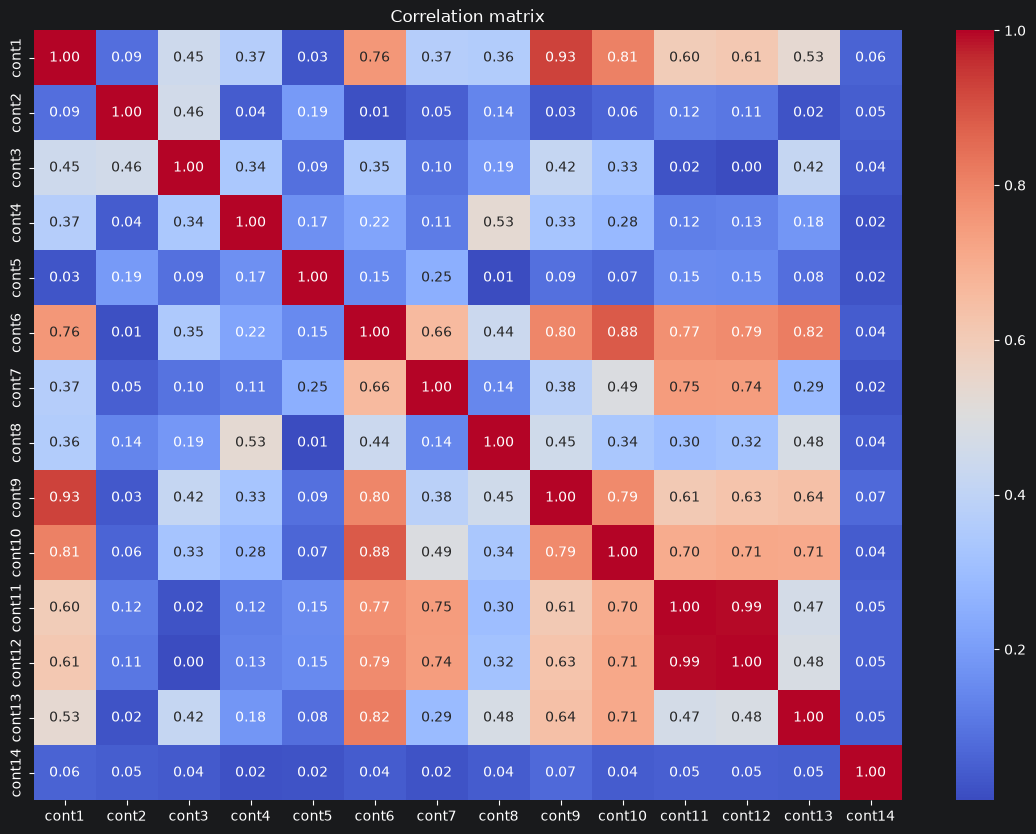

Will be dropped because of high correlation: ['cont9', 'cont12']


In [19]:
draw_corr_matrix(train_df, num_cols, "Correlation matrix")

corr_matrix = train_df[num_cols].corr()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)]

print(f"Will be dropped because of high correlation: {to_drop}")

В выводе этой ячейки будет показан точный список числовых признаков, которые будут удалены из датасета. Это позволит нам убрать сильную мультиколлинеарность (между парами `cont9` и `cont12`) и оставить только самые информативные фичи для Keras.

In [20]:
train_df = train_df.drop(columns=to_drop)
val_df = val_df.drop(columns=to_drop)

num_cols = [col for col in num_cols if col not in to_drop]


В этой ячейке мы переводим строковые текстовые категории в числовой формат, понятный для нейросети, с помощью инструмента `OneHotEncoder` из библиотеки `scikit-learn`.

* Кодировщик настраивается строго на обучающих данных (`fit_transform`) и затем применяется к валидационным (`transform`), чтобы избежать утечки информации.
* Параметр `sparse_output=False` заставляет кодировщик возвращать обычный плотный массив `numpy.ndarray`, а `handle_unknown="ignore"` защищает модель от ошибок, если на тесте вдруг встретится неизвестная категория.


In [21]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
x_train_cat_encoded = encoder.fit_transform(train_df[cat_cols])
x_val_cat_encoded = encoder.transform(val_df[cat_cols])

print(train_df[cat_cols].shape)
print(x_train_cat_encoded.shape)

(150654, 116)
(150654, 1118)


В этой ячейке мы приводим все непрерывные числовые переменные (`cont1`–`cont14`) к единому масштабу с помощью `StandardScaler`.

* Кодировщик настраивается на обучающих данных (`fit_transform`) и применяется к валидационным (`transform`). Это сцентрирует признаки вокруг нуля со стандартным отклонением, равным 1.
* Для визуального контроля результатов мы строим графики «ящиков с усами» (`draw_boxplot`) для исходных и отмасштабированных данных на обоих наборах (`train_df` и `val_df`).




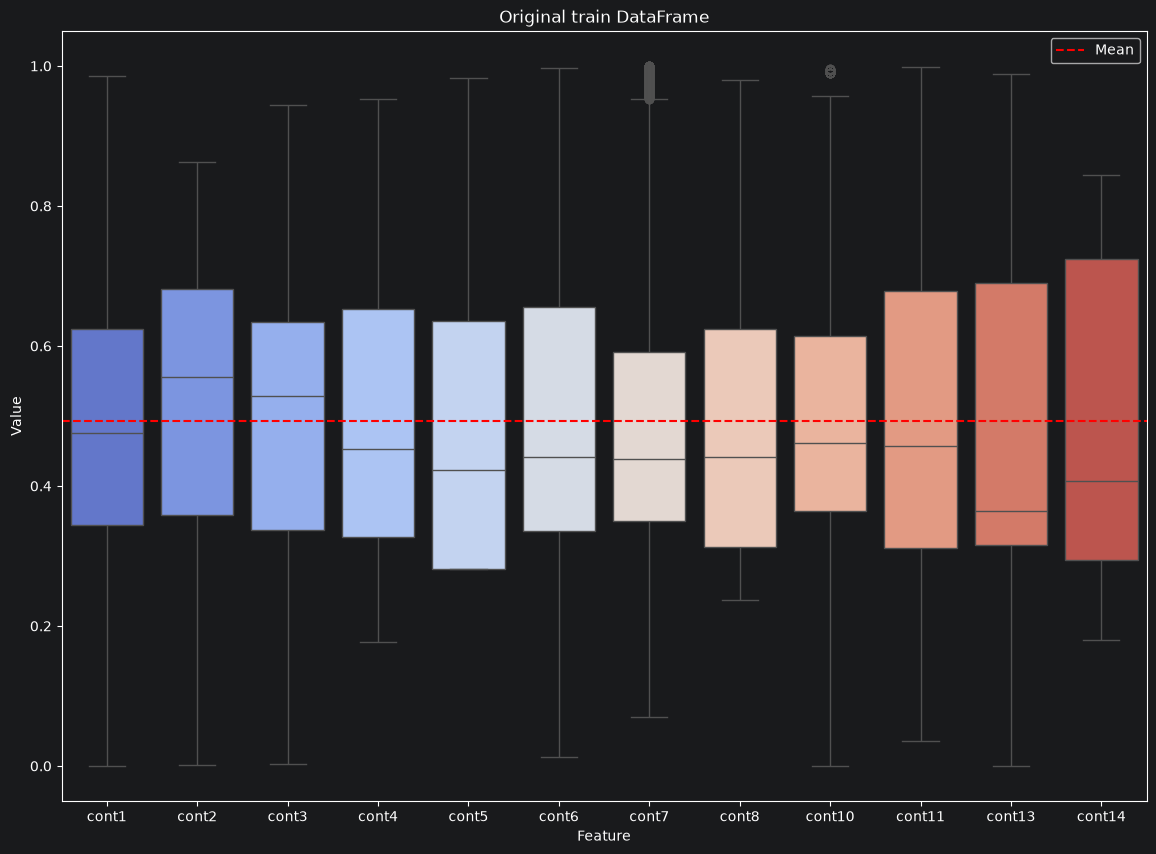

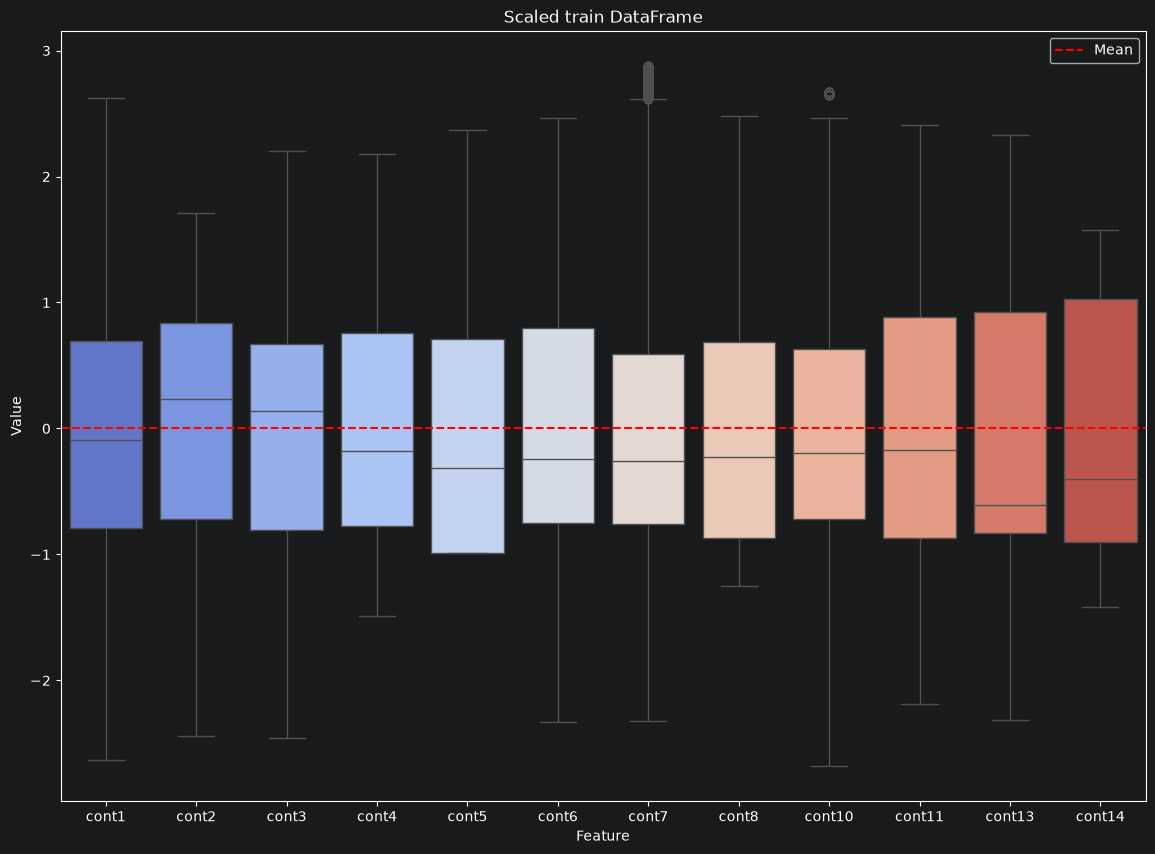

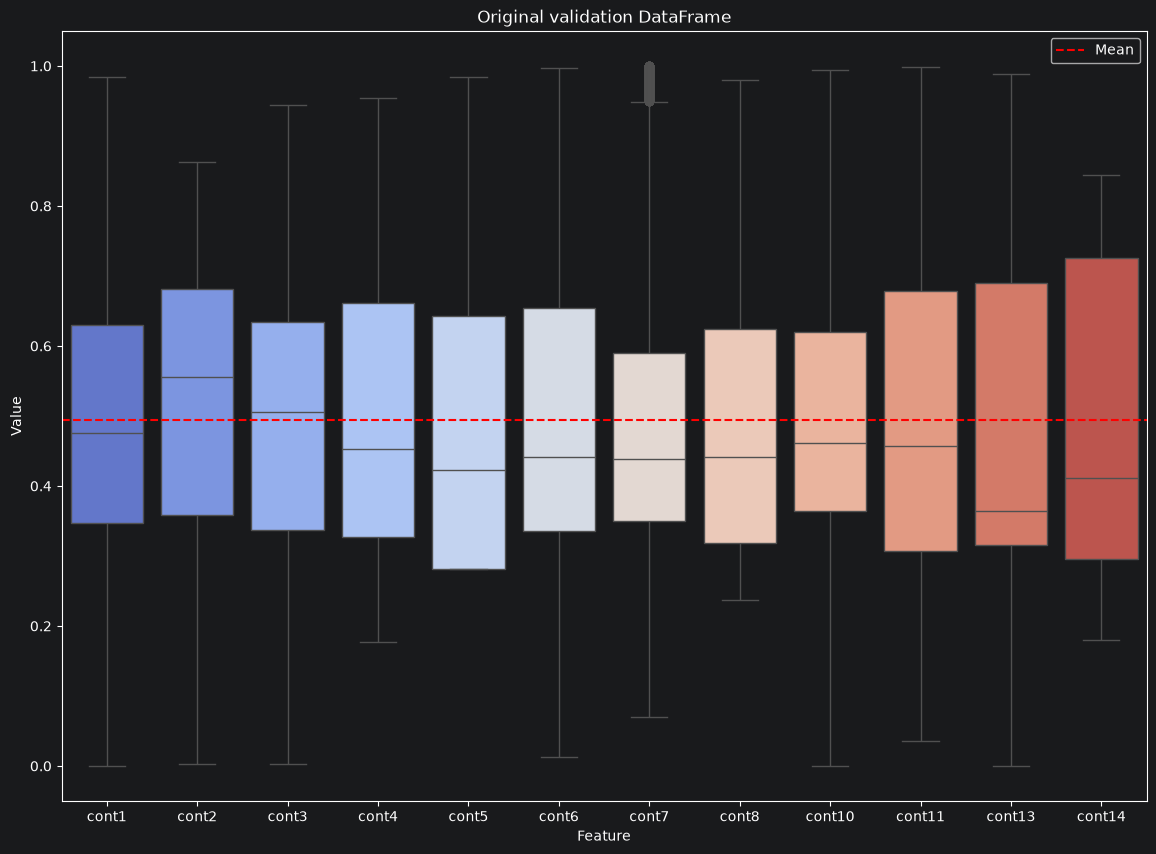

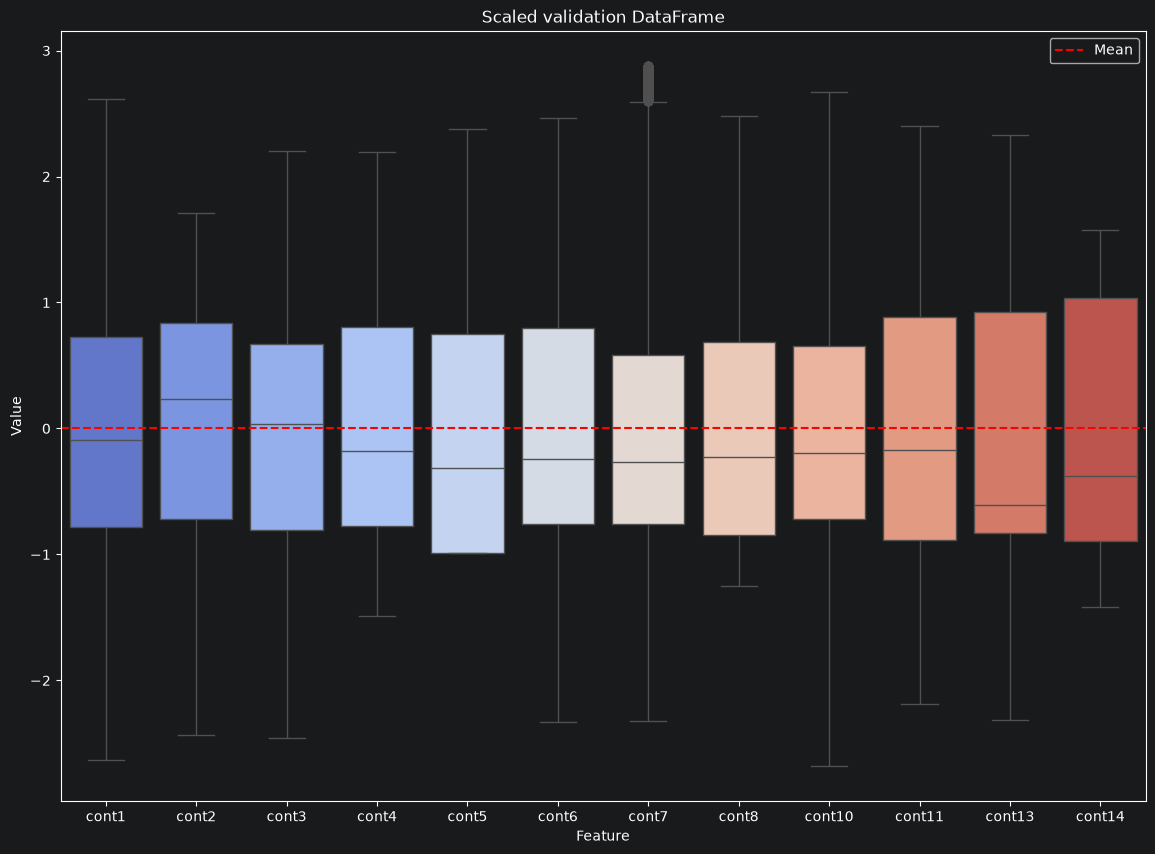

In [22]:
scaler = StandardScaler()
x_train_num_scaled = scaler.fit_transform(train_df[num_cols])
x_val_num_scaled = scaler.transform(val_df[num_cols])

draw_boxplot(train_df, num_cols, "Original train DataFrame")
draw_boxplot(x_train_num_scaled, num_cols, "Scaled train DataFrame")

draw_boxplot(val_df, num_cols, "Original validation DataFrame")
draw_boxplot(x_val_num_scaled, num_cols, "Scaled validation DataFrame")

Графики группы `Original` показывают, что непрерывные признаки в Allstate изначально лежат в диапазоне от 0 до 1, но имеют разные средние значения и дисперсию. Графики группы `Scaled` наглядно подтверждают успешность операции: теперь все числовые фичи лежат в одной сбалансированной системе координат вокруг нуля. Это критически важно для полносвязной модели Keras, так как защищает нейросеть от перекосов и гарантирует плавное и быстрое обучение.

В этой ячейке мы завершаем этап предобработки (Feature Engineering), собирая все признаки в единые массивы, и сохраняем результаты на диск в сжатом бинарном формате.

* С помощью функции `np.column_stack` мы объединяем по горизонтали закодированную категориальную матрицу (`x_cat_encoded`) и масштабированные числовые фичи (`x_num_scaled`). На выходе получаем готовые плотные матрицы `x_train_ready` и `x_val_ready`.
* Из исходных датафреймов извлекаются чистые одномерные массивы ответов `y_train_split` и `y_val_split` в оригинальном долларовом масштабе.
* Метод `np.savez_compressed` упаковывает матрицы признаков (`X`) и целевой переменной (`Y`) в сжатые файлы формата `.npz`.


In [23]:
y_train_split = train_df["loss"].values
y_val_split = val_df["loss"].values

x_train_ready = np.column_stack([x_train_cat_encoded, x_train_num_scaled])
x_val_ready = np.column_stack([x_val_cat_encoded, x_val_num_scaled])

np.savez_compressed(processed_train_path, X=x_train_ready, Y=y_train_split)
np.savez_compressed(processed_val_path, X=x_val_ready, Y=y_val_split)

Сохранение данных в формате `.npz` решает сразу две задачи. Во-первых, файлы занимают в разы меньше места на диске, что критично для тяжелых разреженных One-Hot матриц. Во-вторых, при последующих запусках обучения нам не нужно заново тратить время на работу энкодеров и сплиты -- данные загружаются в память JAX мгновенно, в полностью готовом виде.



В этой ячейке мы настраиваем среду выполнения для Keras 3. Переменная окружения `"KERAS_BACKEND"` принудительно переключает движок расчетов на **JAX** вместо стандартного TensorFlow.

* Метод `jax.devices()` проверяет и выводит список всех доступных вычислительных устройств в системе (видеокарты или процессоры).
* С помощью функции `jax.default_backend()` мы определяем текущую платформу расчетов по умолчанию.




In [24]:
import jax

os.environ["KERAS_BACKEND"] = "jax"

devices = jax.devices()
print(devices)

backend_platform = jax.default_backend()

if backend_platform.lower() == "gpu":
    print("JAX GPU backend")
else:
    print("JAX CPU backend")

[CudaDevice(id=0)]
JAX GPU backend



> **JAX потому что:**
> Использование связки Keras + JAX позволяет значительно сократить время обучения полносвязной модели. Благодаря сквозной XLA-компиляции (Just-In-Time), JAX объединяет математические операции и выполняет их на GPU с максимальной эффективностью. Это особенно заметно на этапе работы с нашей широкой One-Hot матрицей (553 признака) и большим размером батча (1024), где эпохи пролетают практически мгновенно. Логи вывода ячейки наглядно подтверждают, что бэкенд успешно определил графический ускоритель (`JAX GPU backend`).


В этой ячейке мы описываем архитектуру нашей итоговой нейросети.

* **Входной слой (`Input`)**: Принимает вектор `input_share_dim` размерностью > 1000 (после `OneHotEncoder` у нас получается гигантская разреженная матрица).
* **Скрытые слои (`Dense`)**: Модель построена по принципу сужающейся воронки (`128 -> 64 -> 32`). Такой постепенный спад емкости заставляет сеть агрегировать мелкие One-Hot сигналы в более глубокие и компактные нелинейные абстракции. В качестве функций активации используется стандартная `relu`.
* **Регуляризация (`Dropout`)**: На двух первых скрытых слоях добавлены слои `Dropout(0.3)`. Во время каждого прохода обучения они случайным образом отключают 30% нейронов. Это лишает сеть возможности зазубрить обучающий датасет наизусть и жестко блокирует оверфит.
* **Выходной слой**: Одиночный нейрон с линейной активацией (`activation="linear"`), который напрямую прогнозирует непрерывную величину.

Модель оптимизируется популярным методом `Adam` со стандартными настройками шага. В качестве функции потерь (loss) выбран **MAE**.


In [25]:
from keras.models import Sequential
from keras.layers import Input, Dropout, Dense
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

input_share_dim = (x_train_ready.shape[1],)

model = Sequential([
    Input(shape=input_share_dim),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="linear"),
])

model.compile(optimizer="adam", loss="mae", metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       144,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,137 (606.00 KB)

 Trainable params: 155,137 (606.00 KB)

 Non-trainable params: 0 (0.00 B)

В этой ячейке мы запускаем процесс обучения нейросети. Чтобы обучение на протяжении 100 эпох проходило стабильно и не привело к зазубриванию данных, мы подключаем два умных инструмента контроля из библиотеки Keras:

* **`ReduceLROnPlateau`** -- автоматически отслеживает ошибку на валидации (`val_loss`). Если модель топчется на месте 5 эпох подряд (`patience=5`), шаг обучения уменьшается в два раза (`factor=0.5`). Это позволяет сети ювелирно донастроить веса.
* **`EarlyStopping`** -- защищает модель от переобучения. Если ошибка на валидации перестает падать на протяжении 10 эпох подряд (`patience=10`), обучение принудительно останавливается. Флаг `restore_best_weights=True` автоматически возвращает модели те веса, на которых ошибка была самой минимальной.


In [26]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]
history = model.fit(
    x_train_ready, y_train_split,
    epochs=100,
    batch_size=1024,
    validation_data=(x_val_ready, y_val_split),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2171.9678 - mae: 2171.9678 - val_loss: 1706.5729 - val_mae: 1706.5729 - learning_rate: 0.0010
Epoch 2/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1565.3174 - mae: 1565.3174 - val_loss: 1324.6526 - val_mae: 1324.6526 - learning_rate: 0.0010
Epoch 3/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1289.3695 - mae: 1289.3695 - val_loss: 1238.5073 - val_mae: 1238.5073 - learning_rate: 0.0010
Epoch 4/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1249.4720 - mae: 1249.4720 - val_loss: 1210.8937 - val_mae: 1210.8937 - learning_rate: 0.0010
Epoch 5/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1234.7701 - mae: 1234.7701 - val_loss: 1203.4312 - val_mae: 1203.4312 - learning_rate: 0.0010
Epoch 6/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1225.5995 - mae: 1225.5995 - val_loss: 1197.4135 - val_mae: 1197.4135 - learning_rate: 0.0010
Epoch 7/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1220.083

При обучении были достигнуты следующие параметры:

* **Loss (MAE)** = 1153.1703
* **Validation loss** = 1165.2096

В этой ячейке мы делаем финальный шаг -- оцениваем качество обученной Sequential-модели на отложенных тестовых данных, которые она не видела в процессе обучения, и строим график остатков.

* С помощью метода `model.predict()` мы получаем прогнозы выплат по всей тестовой выборке.
* Рассчитываем ключевые метрики в исходном долларовом масштабе: **MAE** (среднее абсолютное отклонение) и **RMSE** (среднеквадратическую ошибку для контроля крупных промахов).
* Передаем реальные ответы `y_val_split` и предсказания `y_pred` в нашу кастомную функцию `draw_residual_plot` для визуализации ошибок.




1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 390us/step
MAE: 1164.8418485042212, RMSE: 1918.7459731292086


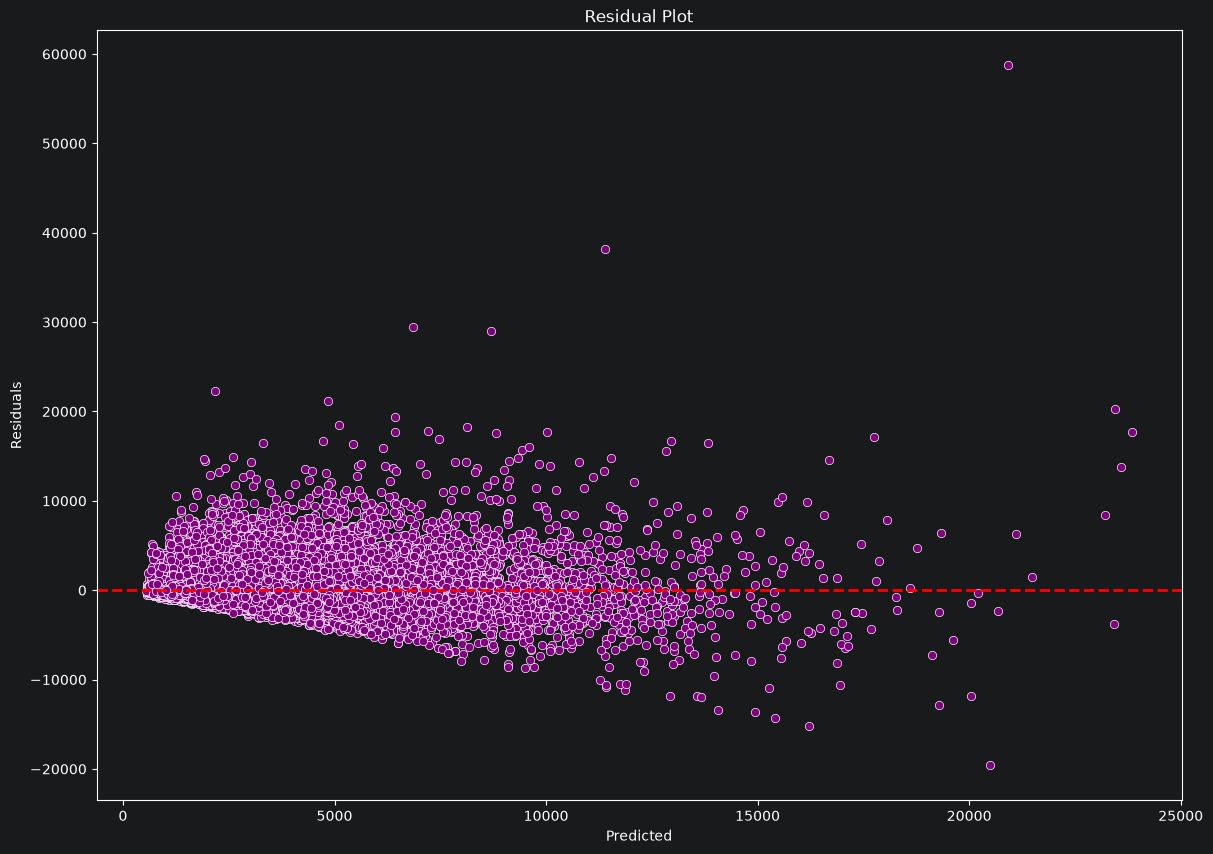

In [27]:
y_pred = model.predict(x_val_ready).flatten()
final_mae = mean_absolute_error(y_val_split, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_val_split, y_pred))
print(f"MAE: {final_mae}, RMSE: {final_rmse}")

draw_residual_plot(y_val_split, y_pred)

Полученный результат MAE находится на уровне **1164.84**, а RMSE составляет **1918.76**. Модель не переобучилась и показала стабильный базовый результат.

На графике видно, что плотное «облако» остатков симметрично и очень ровно группируется вокруг нулевой красной пунктирной линии в широком диапазоне предсказаний -- **от 1 000 до 13 000**. Это наглядно доказывает, что нейросеть отлично выучила и стабильно предсказывает подавляющее большинство (массовый, типичный сегмент) страховых случаев в датасете.

Начиная с отметки предсказаний в 13 000 и далее вправо, плотность точек падает, а само «облако» начинает заметно смещаться вверх (остатки уходят в положительную зону до +30 000 и +60 000). Это означает, что реальные выплаты там оказались гораздо выше, чем спрогнозировала сеть. Данный эффект наглядно подтверждает консерватизм полносвязных нейросетей на сильно скошенных данных -- модель сознательно занижает прогнозы по редким аномальным супер-выплатам (выбросам), чтобы не ломать общую сходимость градиентов и удерживать глобальную ошибку MAE на минимальном уровне по всей выборке.


## Чистый энтузиазм

> Мне стало дико интересно проверить, смогу ли я с помощью новомодных архитектурных приемов глубокого обучения перешагнуть плато точности нашей базовой модели и еще сильнее уменьшить лосс на валидации.

В ходе этого мини-исследования я решил отказаться от стандартного One-Hot кодирования и простых последовательных слоев, чтобы построить гибридную нейросеть, совмещающую концепции эмбеддингов, остаточных связей, как в трансформерах, и нормализацию признаков.



Тут я решил поменять стратегию. Вместо того чтобы пичкать нейросеть сырыми долларами, мы сглаживаем значения через логарифм, но не простой, а со сдвигом на 400:

> В страховых выплатах есть дикие выбросы — куча мелких сумм и редкие выплаты по 100 тысяч долларов. Из-за этого градиенты модели штормит. Логарифм красиво сплющивает масштаб, а сдвиг на 400 оставляет крупным выплатам достаточно веса. Модель перестает паниковать из-за огромных чисел, но при этом не забывает про дорогие страховые случаи, что спасает итоговую метрику RMSE от взрыва. Работает магия. Ни разу не пожалел, что решил почиать про это.


In [28]:
shift = 400

y_train_log = np.log(y_train_split + shift)
y_val_log = np.log(y_val_split + shift)


Для сложной сети One-Hot кодирование не подходит — матрица получается слишком огромной. Поэтому я взял `OrdinalEncoder` из Scikit-Learn.

* Переводим буквы в обычные целые числа (`np.int32`).
* Делаем сдвиг `+= 1`, чтобы в данных не было отрицательных индексов (кодировщик ставит их, если натыкается на новое неизвестное значение).
* Собираем словарь `cat_cardinalities`. Он автоматически считает, сколько уникальных букв-классов есть в каждой из 116 колонок. Это нужно, чтобы Keras точно знал, какого размера делать слои эмбеддингов (Embedding) и не сожрал лишнюю память.


In [29]:
ord_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
x_train_cat_ord = ord_encoder.fit_transform(train_df[cat_cols]).astype(np.int32)
x_val_cat_ord = ord_encoder.transform(val_df[cat_cols]).astype(np.int32)

x_val_cat_ord += 1
x_train_cat_ord += 1

cat_cardinalities = {
    col: int(max(x_train_cat_ord[:, i].max(), x_val_cat_ord[:, i].max()) + 1)
    for i, col in enumerate(cat_cols)
}

Тут начала происходить магия меня, тонны литературы и веба.

1. **Эмбеддинги (`Embedding`)**: Каждая текстовая колонка заходит в свой мини-слой, который превращает буквы в плотные векторы. Похожие по смыслу и рискам категории в процессе обучения сами сближаются друг с другом.

2. **Комбо из нормализаций**: На числовой вход я поставил `BatchNormalization` — там он работает отлично. А вот внутри скрытых слоев я заменил его на **`LayerNormalization`**. Это помогло спасти редкие категории из колонки `cat116` (где больше 300 уникальных значений). BatchNorm их просто стирал и размывал по батчу 1024, а LayerNorm нормализует каждую строчку отдельно, сохраняя важные уникальные сигналы.

3. **Pre-Activation ResNet блоки**: Слои идут в самом стабильном порядке: `LayerNorm -> ReLU → Dropout -> Dense`. А метод `add([x, res])` перекидывает мостики для градиентов, чтобы они без барьеров летели через бэкенд JAX на GPU.

4. **Выход и обратный пересчет**: Обучаемся строго на `loss="mae"` с огромным запасом в колбэках (`patience=20`). В самом конце логарифмы превращаем обратно в нормальные доллары через экспоненту и вычитаем наш сдвиг: `np.exp(pred) - 400`.

> Магия пре-активации заключается в том, что если писать слои в стандартном виде: `Dense -> LayerNorm -> ReLU`, то у нас к моменту складывания будут данные строго положительные и по сути фильтрованные. Если мы перевернем систему, то у нас слой будет выводы складывать до своей активации и нормализации, что и дает чистый сигнал. Кроме того пропадает проблема ненормализованных данных. У нас после того как результаты склеятся они нормализуются, и следующий слой берет хорошие данные.


In [30]:
import keras
from keras.layers import Input, Dropout, Dense, BatchNormalization, Activation, add, Embedding, Flatten, Concatenate, \
    LayerNormalization
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

inputs = []
embeddings = []

for i, col in enumerate(cat_cols):
    num_classes = cat_cardinalities[col]

    emb_dim = min(50, (num_classes + 1) // 2)
    if emb_dim < 2:
        emb_dim = 2

    inp = Input(shape=(1,), name=f"input_{col}")
    emb = Embedding(input_dim=num_classes + 1, output_dim=emb_dim, name=f"embedding_{col}")(inp)
    emb = Flatten()(emb)

    inputs.append(inp)
    embeddings.append(emb)

num_inputs = Input(shape=(len(num_cols),), name="num_inputs")
inputs.append(num_inputs)

num_normalized = BatchNormalization(name="batch_norm_num")(num_inputs)

all_features = Concatenate()(embeddings + [num_normalized])
print(all_features.shape)

x = Dense(512, use_bias=False)(all_features)
x = LayerNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.2)(x)

res1 = x
x = LayerNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.2)(x)
x = Dense(512, use_bias=False)(x)
x = add([x, res1])

res2 = x
x = LayerNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.2)(x)
x = Dense(512, use_bias=False)(x)
x = add([x, res2])

x = LayerNormalization()(x)
x = Activation("relu")(x)

x = Dense(256, use_bias=False)(x)
x = Dropout(0.1)(x)

x = Dense(64, use_bias=False)(x)

output = Dense(1, activation="linear")(x)

model = keras.Model(inputs=inputs, outputs=output)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.002), loss="mae", metrics=["mae"])

train_inputs = [x_train_cat_ord[:, i] for i in range(len(cat_cols))] + [x_train_num_scaled]
val_inputs = [x_val_cat_ord[:, i] for i in range(len(cat_cols))] + [x_val_num_scaled]

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
]

model.fit(
    x=train_inputs,
    y=y_train_log,
    validation_data=(val_inputs, y_val_log),
    epochs=100,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1,
)

pred_logs = model.predict(val_inputs).flatten()

pred_real = np.exp(pred_logs) - shift
pred_real = np.clip(pred_real, 0, None)

final_mae = mean_absolute_error(y_val_split, pred_real)
final_rmse = np.sqrt(mean_squared_error(y_val_split, pred_real))

print(f"MAE: {final_mae}, RMSE: {final_rmse}")


(None, 553)
Epoch 1/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - loss: 0.8920 - mae: 0.8920 - val_loss: 0.3697 - val_mae: 0.3697 - learning_rate: 0.0020
Epoch 2/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.4308 - mae: 0.4308 - val_loss: 0.6211 - val_mae: 0.6211 - learning_rate: 0.0020
Epoch 3/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4387 - mae: 0.4387 - val_loss: 0.3595 - val_mae: 0.3595 - learning_rate: 0.0020
Epoch 4/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4145 - mae: 0.4145 - val_loss: 0.4025 - val_mae: 0.4025 - learning_rate: 0.0020
Epoch 5/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4021 - mae: 0.4021 - val_loss: 0.3703 - val_mae: 0.3703 - learning_rate: 0.0020
Epoch 6/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4077 - mae: 0.4077 - val_loss: 0.3573 - val_mae: 0.3573 - learning_rate: 0.0020
Epoch 7/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.4038 - mae: 0.4038 - val_loss: 0.4980 - val_mae: 0.4980 - l

> * **MAE упал до рекордных 1149.90** (я пробили отметку в 1150!).
> * **RMSE рухнул до фантастических 1895.84** (минус 23 ошибки по сравнению с базовой сетью).


Сдвиг таргета на `400` в паре с лоссом `mae` идеально выровнял баланс между средними и крупными выплатами. Схема `Pre-Activation` защитила веса от раздувания, дав модели колоссальную стабильность на протяжении всех 100 эпох. В отличие от BatchNorm, который размывал редкие категории по батчу 1024, LayerNorm бережно сохранил уникальные сигналы сложных фичей (вроде `cat116`). Сеть смогла детально выучить профиль дорогих и нестандартных страховых случаев, что и привело к мощнейшему падению RMSE.
